In [39]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [40]:
# Make output folder
output_dir = '../plots'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [41]:
sequence_path = os.path.join('/Users', 'kenneth.van.der.zee', 'Documents', 'phd_1_task', 'resources', 'parameters_per_stimuli_sub-008_session-01.csv')
sequence_dataframe = pd.read_csv(sequence_path)

# Adding a helper column 'entry' to keep track of the count of each type
sequence_dataframe['entry'] = sequence_dataframe.groupby('stimuli_type').cumcount()

# Pivot the DataFrame using the new 'entry' column as the index
sequence_dataframe_pivoted = sequence_dataframe.pivot(index = 'entry', columns = 'stimuli_type', values = 'probability_sequence')
print(sequence_dataframe_pivoted)

stimuli_type     1     2     3     4
entry                               
0             50.0  50.0  50.0  50.0
1             50.0  50.0  50.0  50.0
2             80.0  50.0  50.0  50.0
3             80.0  50.0  50.0  50.0
4             80.0  20.0  20.0  20.0
...            ...   ...   ...   ...
115           80.0  20.0  80.0  80.0
116           80.0  20.0  80.0  80.0
117           80.0  20.0  80.0  80.0
118           80.0  20.0  80.0  80.0
119           80.0  20.0  80.0  80.0

[120 rows x 4 columns]


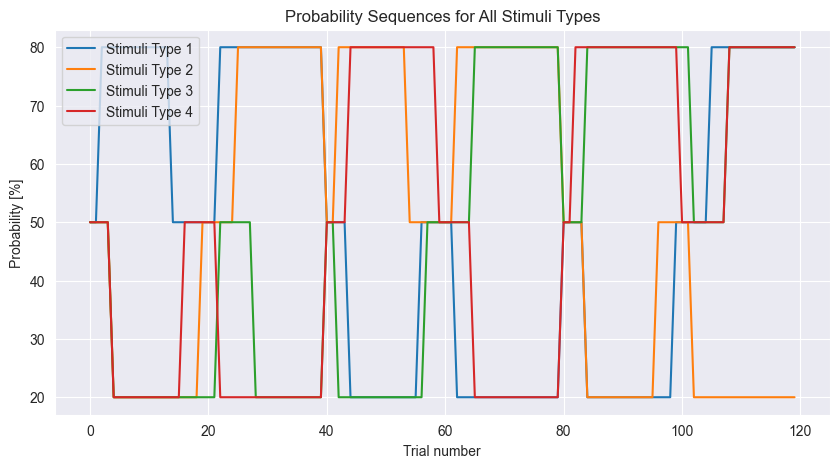

In [42]:
# Plot all stimuli types together
plt.figure(figsize=(10, 5))
for col in sequence_dataframe_pivoted.columns:
    plt.plot(sequence_dataframe_pivoted[col], label=f'Stimuli Type {col}')
plt.title('Probability Sequences for All Stimuli Types')
plt.xlabel('Trial number')
plt.ylabel('Probability [%]')
plt.legend()
plt.savefig(os.path.join(output_dir, 'probability_sequence_all_stimuli_types.pdf'))
plt.show()

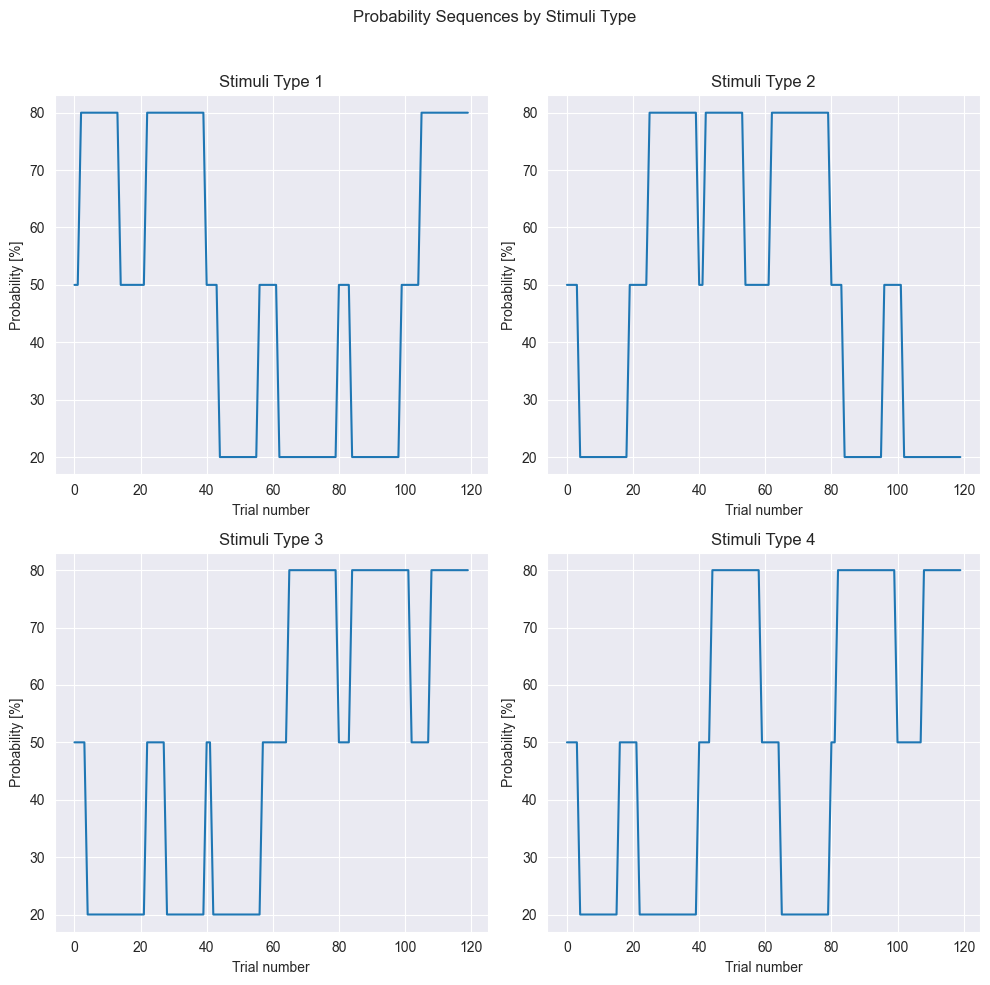

In [43]:
# Plot each stimuli type in a separate subplot
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
fig.suptitle('Probability Sequences by Stimuli Type')

for i, ax in enumerate(axes.flatten()):
    ax.plot(sequence_dataframe_pivoted[i+1].dropna())  # dropna() is used because pivoting can introduce NaN values
    ax.set_title(f'Stimuli Type {i+1}')
    ax.set_xlabel('Trial number')
    ax.set_ylabel('Probability [%]')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust the layout to make room for the main title
plt.savefig(os.path.join(output_dir, 'probability_sequence_per_stimuli_type.pdf'))
plt.show()